In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

%matplotlib inline

print("Advanced Analytics Libraries Imported Successfully!")

Advanced Analytics Libraries Imported Successfully!


In [40]:
# Load datasets

nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [41]:
print("NAV History")
display(nav_history.head())

print("Transactions")
display(transactions.head())

print("Performance")
display(performance.head())

print("Portfolio")
display(portfolio.head())

NAV History


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


Transactions


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


Performance


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


Portfolio


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [42]:
# Convert date column to datetime

nav_history["date"] = pd.to_datetime(nav_history["date"])

print(nav_history.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [43]:
# Sort NAV history

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [44]:
# Daily Returns

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [45]:
# Historical VaR (95%)

var_95 = (
    nav_history["daily_return"]
    .dropna()
    .quantile(0.05)
)

print(f"Historical VaR (95%): {var_95:.4f}")

Historical VaR (95%): -0.0163


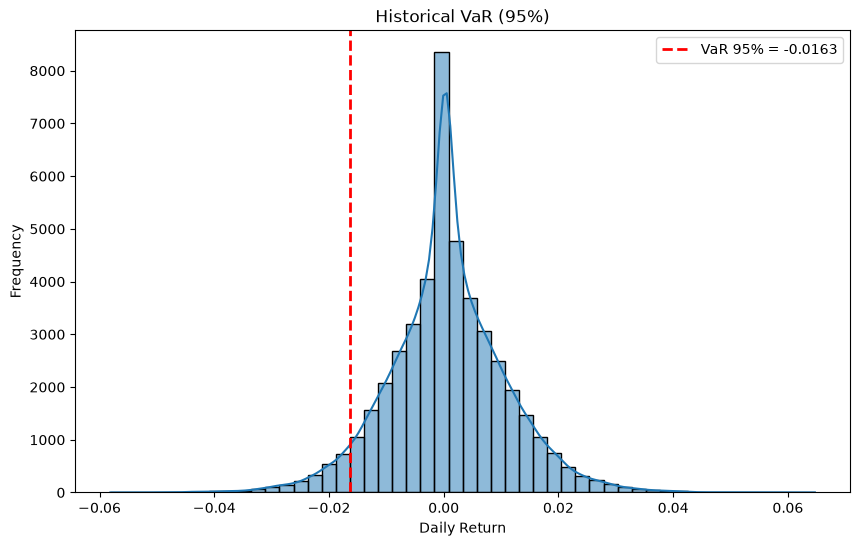

In [46]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.axvline(
    var_95,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"VaR 95% = {var_95:.4f}"
)

plt.title("Historical VaR (95%)")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [47]:
# Select one mutual fund

fund = nav_history[nav_history["amfi_code"] == nav_history["amfi_code"].iloc[0]].copy()

fund.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [48]:
risk_free_rate = 0.065 / 252

fund["rolling_sharpe"] = (
    (
        fund["daily_return"].rolling(90).mean() - risk_free_rate
    )
    /
    fund["daily_return"].rolling(90).std()
) * np.sqrt(252)

fund.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN


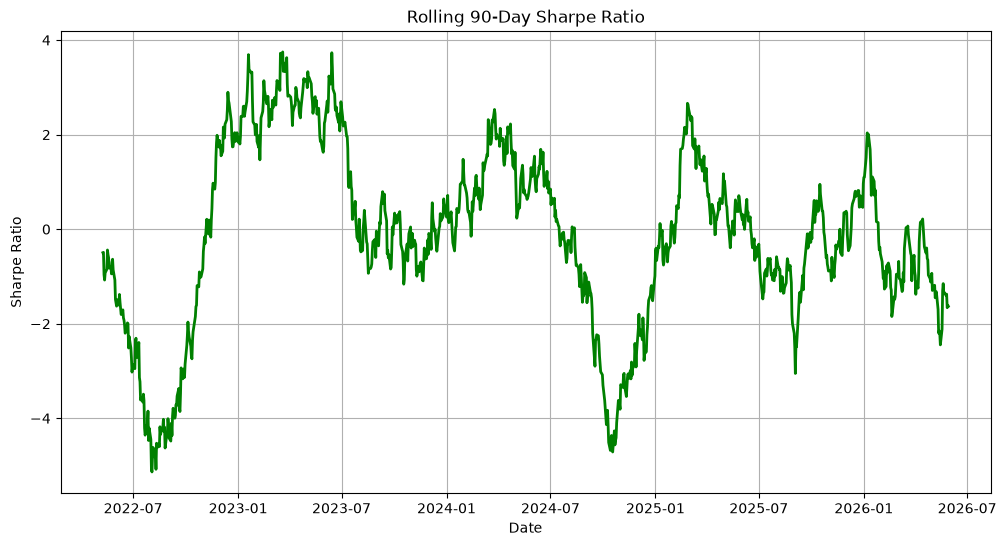

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    fund["date"],
    fund["rolling_sharpe"],
    color="green",
    linewidth=2
)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.show()

In [50]:
# Convert transaction date

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [51]:
# Find first investment date for every investor

first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn.rename(
    columns={"transaction_date": "first_transaction"},
    inplace=True
)

first_txn.head()

,investor_id,first_transaction
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [52]:
# Create cohort year

first_txn["cohort_year"] = (
    first_txn["first_transaction"].dt.year
)

first_txn.head()

,investor_id,first_transaction,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [53]:
# Merge cohort information

transactions = transactions.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [54]:
# Cohort analysis summary

cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        Investors=("investor_id", "nunique"),
        Total_Investment=("amount_inr", "sum"),
        Average_Investment=("amount_inr", "mean")
    )
)

cohort_summary

,Investors,Total_Investment,Average_Investment
cohort_year,,,
2024,4803,3491125187,107422.541832
2025,197,30455243,109158.577061


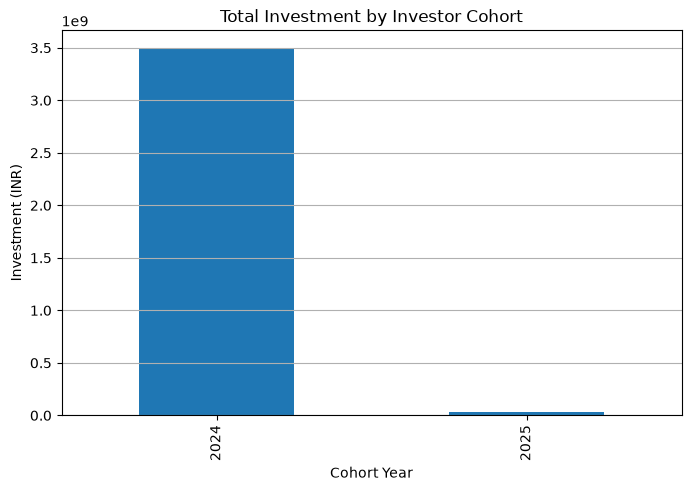

In [55]:
plt.figure(figsize=(8,5))

cohort_summary["Total_Investment"].plot(kind="bar")

plt.title("Total Investment by Investor Cohort")
plt.xlabel("Cohort Year")
plt.ylabel("Investment (INR)")

plt.grid(axis="y")

plt.show()

In [56]:
# Sort transactions by investor and date

transactions = transactions.sort_values(
    ["investor_id", "transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024


In [57]:
# Previous transaction date

transactions["previous_transaction"] = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .shift(1)
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,previous_transaction
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaT
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,2024-11-04
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,2025-01-14
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaT
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,2024-03-29


In [58]:
# Calculate gap in days

transactions["gap_days"] = (
    transactions["transaction_date"] -
    transactions["previous_transaction"]
).dt.days

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,previous_transaction,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaT,NaN
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,2024-11-04,71.0
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,2025-01-14,5.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaT,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,2024-03-29,107.0


In [59]:
# Investors with SIP gap > 35 days

transactions["at_risk"] = transactions["gap_days"] > 35

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,previous_transaction,gap_days,at_risk
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaT,NaN,False
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,2024-11-04,71.0,True
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,2025-01-14,5.0,False
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaT,NaN,False
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,2024-03-29,107.0,True


In [60]:
risk_summary = (
    transactions
    .groupby("at_risk")
    .agg(
        Investors=("investor_id", "nunique")
    )
)

risk_summary

,Investors
at_risk,
False,5000
True,4527


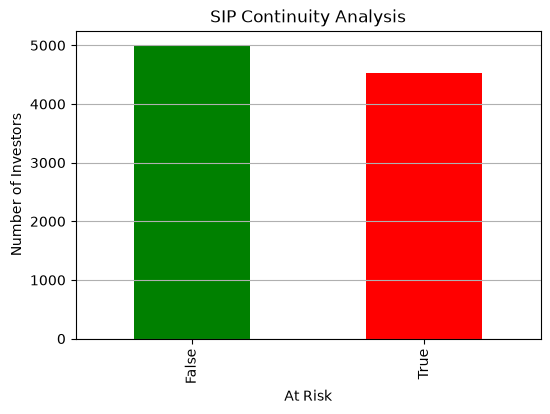

In [61]:
plt.figure(figsize=(6,4))

risk_summary["Investors"].plot(kind="bar", color=["green", "red"])

plt.title("SIP Continuity Analysis")
plt.xlabel("At Risk")
plt.ylabel("Number of Investors")

plt.grid(axis="y")

plt.show()

In [62]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [63]:
# Keep only required columns

recommend = performance[
    ["scheme_name", "risk_grade", "sharpe_ratio"]
].copy()

recommend["sharpe_ratio"] = pd.to_numeric(
    recommend["sharpe_ratio"],
    errors="coerce"
)

recommend = recommend.dropna()

recommend.head()

,scheme_name,risk_grade,sharpe_ratio
0,SBI Bluechip Fund - Regular Plan - Growth,Moderate,0.88
1,SBI Bluechip Fund - Direct Plan - Growth,Moderate,0.81
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94
3,SBI Small Cap Fund - Direct Plan - Growth,Very High,0.93
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,1.52


In [64]:
def recommend_funds(risk_level):
    """
    Recommend Top 3 funds based on risk grade
    """

    filtered = recommend[
        recommend["risk_grade"].str.lower() == risk_level.lower()
    ]

    filtered = filtered.sort_values(
        by="sharpe_ratio",
        ascending=False
    )

    return filtered.head(3)

In [65]:
recommend_funds("Low")

,scheme_name,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Low,5.14


In [66]:
recommend_funds("Moderate")

,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [67]:
recommend_funds("High")

,scheme_name,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
38,DSP Midcap Fund - Regular - Growth,High,0.90


In [68]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [69]:
print(performance["risk_grade"].unique())

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str


In [70]:
print(portfolio.columns)

portfolio.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [71]:
portfolio["weight_pct"] = pd.to_numeric(
    portfolio["weight_pct"],
    errors="coerce"
)

In [72]:
sector_weights = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [73]:
sector_weights = sector_weights / 100

sector_weights.head()

sector
Banking       6.5226
IT            4.5547
Pharma        4.0745
Automobile    3.2365
Utilities     2.6554
Name: weight_pct, dtype: float64

In [74]:
hhi = (sector_weights ** 2).sum()

print(f"Portfolio HHI: {hhi:.4f}")

Portfolio HHI: 117.6909


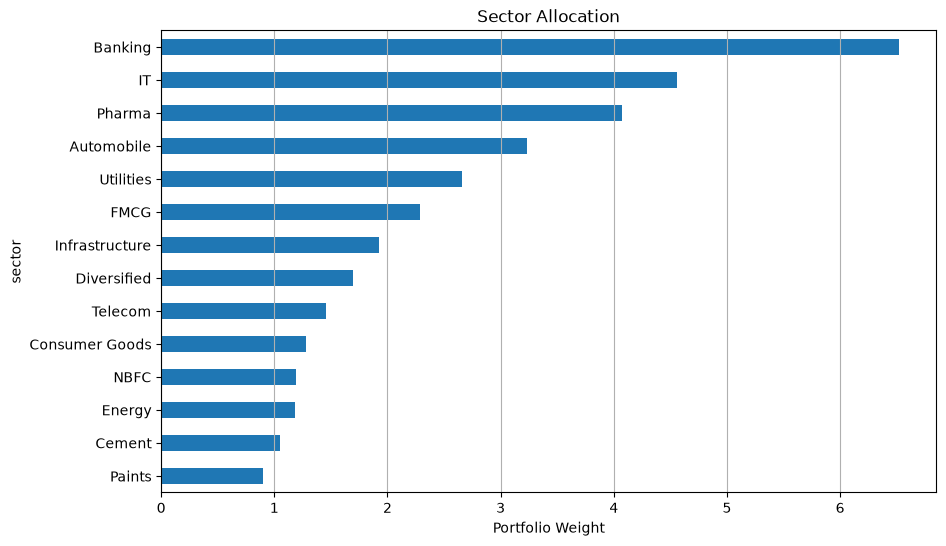

In [75]:
plt.figure(figsize=(10,6))

sector_weights.sort_values().plot(kind="barh")

plt.title("Sector Allocation")
plt.xlabel("Portfolio Weight")

plt.grid(axis="x")

plt.show()

In [76]:
if hhi < 0.15:
    print("Portfolio is Well Diversified")

elif hhi < 0.25:
    print("Portfolio is Moderately Concentrated")

else:
    print("Portfolio is Highly Concentrated")

Portfolio is Highly Concentrated


1. Historical VaR shows the expected maximum daily loss at the 95% confidence level.

2. Rolling Sharpe Ratio indicates that the fund delivered strong risk-adjusted returns during 2023 but experienced periods of weaker performance in late 2024.

3. Investor Cohort Analysis shows that the 2024 cohort contributed the highest total investment, indicating strong investor participation during that year.

4. SIP Continuity Analysis identified investors with gaps greater than 35 days, helping identify potentially inactive or at-risk investors.


5. Sector HHI indicates whether the portfolio is well diversified or concentrated, enabling better portfolio risk assessment.